In [1]:
! pip install -e .
! pip install lifelines


Obtaining file:///home/jovyan/Precipitation_paper
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for precip_helper (pyproject.toml) ... done
  Created wheel for precip_helper: filename=precip_helper-0.1.0-0.editable-py3-none-any.whl size=1298 sha256=fa334b734e69f6fc391f82477b67e2f31f1335bb26c650922192df8b1d4a126c
  Stored in directory: /tmp/pip-ephem-wheel-cache-b4vbxi_w/wheels/0d/d8/f6/0e90ec4164bf3c02bf3bed8ede68ddfb64e3b2ef0023ebb734
Successfully built precip_helper
  Attempting uninstall: precip_helper
    Found existing installation: precip_helper 0.1.0
    Uninstalling precip_helper-0.1.0:
      Successfully uninstalled precip_helper-0.1.0


In [2]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os
import numpy as np
from lifelines import CoxPHFitter


warnings.filterwarnings('ignore')
%matplotlib inline

%load_ext autoreload
%autoreload 2


from precip_helper.utils import read_in_fires_and_precip

In [3]:
fires = read_in_fires_and_precip()

In [4]:
#fires = fires[fires.l1_ecoregion != "GREAT PLAINS"]

In [5]:
### Reformatting the DF to be in the shape expected by lifelines. 

def get_cox_format(df):
    
    af_mask =  (df['start_off_12hrs'] >= 0) & (df['end_off_12hrs'] <= 1)
    new_df = pd.DataFrame({"UfireID" : df.UfireID.unique(), 
                          "duration" : df.duration.max(),
                          "ended": 1,
                          "precip_during_fire": df[af_mask].precipitation.sum(), 
                          "precip_post_fire": df[df.end_off_12hrs == 1].precipitation.unique(), 
                          "farea_final": df.farea.max(),
                          "n_pixels": df.n_pixels.max(),
                          "GACCAbbrev":  df.GACCAbbrev.unique(), 
                         'l1_ecoregion': df.l1_ecoregion.unique(), 
                         'number_of_rain_events': len(df[af_mask & (df.precipitation > 0)].precipitation)})

    return(new_df)

reg_fr = fires.groupby("UfireID").apply(get_cox_format).reset_index(drop = True)

reg_fr.loc[:, "total_precip"] = reg_fr.precip_post_fire + reg_fr.precip_during_fire


<lifelines.CoxPHFitter: fitted with 3596 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'ended'
      baseline estimation = breslow
   number of observations = 3596
number of events observed = 3596
   partial log-likelihood = -24757.64
         time fit was run = 2026-07-15 12:54:13 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
number_of_rain_events -0.17      0.85      0.00           -0.17           -0.16                0.84                0.85

                       cmp to      z      p  -log2(p)
covariate                                            
number_of_rain_events    0.00 -37.33 <0.005   1010.65
---
Concordance = 0.77
Partial AIC = 49517.29
log-likelihood ratio test = 2187.79 on 1 df
-log2(p) of ll-ratio test = inf

<Axes: xlabel='log(HR) (95% CI)'>

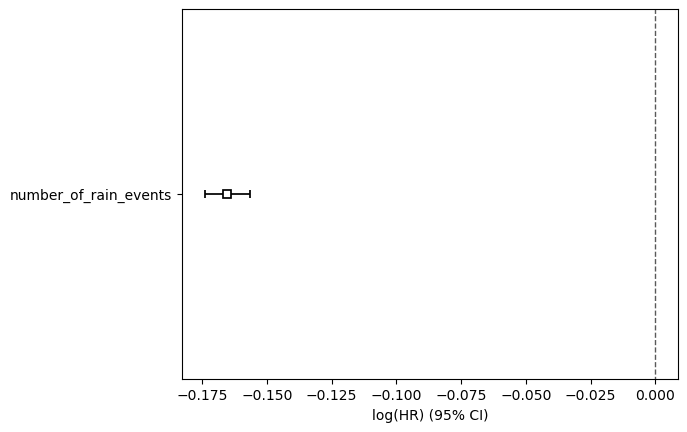

In [6]:
cph = CoxPHFitter()
# df must contain the covariates, the duration (time), and the event observed (boolean/int)

cph.fit(reg_fr[['duration', 'ended', 'number_of_rain_events']], duration_col='duration', event_col='ended')
cph.print_summary()
cph.plot()

Text(0.5, 0, 'Presumably 12-hour increments survived')

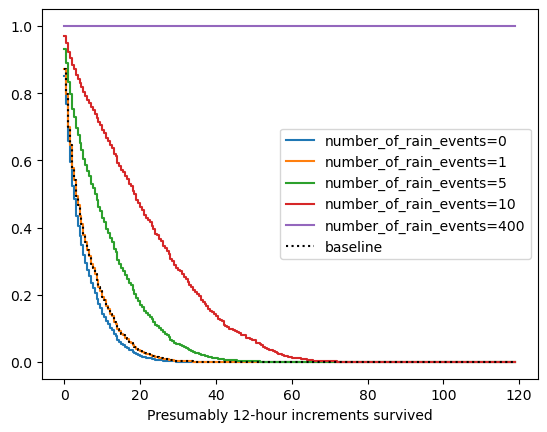

In [7]:
cph.plot_partial_effects_on_outcome(covariates= "number_of_rain_events", values = [0, 1, 5, 10, 400])
plt.xlabel("Presumably 12-hour increments survived")

# Haha, looks like becuase precip varies through time, we are only capturing the effect of more time = more precip. Need to implement a time-varying related model

In [8]:
## get the data into the weird format first. I followed https://lifelines.readthedocs.io/en/latest/Time%20varying%20survival%20regression.html

foo = fires[fires.UfireID == "10047_2022"]

## can the stop be equal to the start????? Lets find out! 

def cox_time_vary_format(df): # cuts off pre-fire precip, but includes post-fire precip 12 hour increment

    post_ig =  (df['start_off_12hrs'] >= 0) & (df.end_off_12hrs < 2) ## we could include more here. 
    df.loc[post_ig & (df.area_growth_at_t_km2.isna()), "area_growth_at_t_km2"] = 0 # include the real zero at the 12 hour mark, negated by the end event?
    end_marker = df[df.end_off_12hrs == 1].start_off_12hrs.values[0]

    
    new_df = pd.DataFrame({ 
                          "start" : df[post_ig].start_off_12hrs,
                          "stop":  df[post_ig].start_off_12hrs + 1,
                          "precipitation": df[post_ig].precipitation,
        
                          "area_growth_at_t_km2": df[post_ig].area_growth_at_t_km2,
                          #n_pixels": df.n_pixels,
                          #"GACCAbbrev":  df.GACCAbbrev.unique(), 
                         #'number_of_rain_events': len(df[post_ig & (df.precipitation > 0)].precipitation), # not time varying right now. 
        
                          })
    new_df.loc[:, "precip_bool"] = new_df.precipitation > 1 ### The more I increase this boolean, the larger the effect. This makes sense because we would expect more rain to put out fires. 
    new_df.loc[:, "precip_cumsum"] = df[post_ig].precipitation.cumsum()
    new_df.loc[:, 'l1_ecoregion'] = df.l1_ecoregion.unique()[0]
    new_df.loc[:, "UfireID"] =  df.UfireID.unique()[0]
    new_df.loc[:, "GACCAbbrev"] = df.GACCAbbrev.unique()[0]
    new_df.loc[:, "ended"] = 0
    new_df.loc[new_df.start == end_marker, "ended"] = 1

    return(new_df)
    
    

In [9]:
tmp = cox_time_vary_format(foo)

tmp

,start,stop,precipitation,area_growth_at_t_km2,precip_bool,precip_cumsum,l1_ecoregion,UfireID,GACCAbbrev,ended
34,0.0,1.0,0.00,4.105439,False,0.00,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
35,1.0,2.0,0.00,0.000000,False,0.00,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
36,2.0,3.0,0.00,0.000000,False,0.00,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
37,3.0,4.0,0.00,0.000000,False,0.00,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
38,4.0,5.0,0.00,0.000000,False,0.00,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
39,5.0,6.0,0.83,0.000000,False,0.83,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
40,6.0,7.0,0.00,0.000000,False,0.83,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
41,7.0,8.0,0.00,0.000000,False,0.83,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
42,8.0,9.0,0.00,0.000000,False,0.83,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
43,9.0,10.0,0.00,0.000000,False,0.83,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0


In [10]:
fr_tv = fires.groupby("UfireID").apply(cox_time_vary_format).reset_index(drop = True)

Iteration 1: norm_delta = 2.38e-01, step_size = 0.9500, log_lik = -25931.15176, newton_decrement = 1.19e+02, seconds_since_start = 0.1
Iteration 2: norm_delta = 6.68e-02, step_size = 0.9500, log_lik = -26238.44991, newton_decrement = 2.88e+02, seconds_since_start = 0.2
Iteration 3: norm_delta = 3.42e-02, step_size = 0.9500, log_lik = -25917.06638, newton_decrement = 3.78e+01, seconds_since_start = 0.3
Iteration 4: norm_delta = 2.07e-02, step_size = 1.0000, log_lik = -25873.19298, newton_decrement = 6.50e+00, seconds_since_start = 0.3
Iteration 5: norm_delta = 5.45e-03, step_size = 1.0000, log_lik = -25865.90094, newton_decrement = 3.01e-01, seconds_since_start = 0.4
Iteration 6: norm_delta = 2.94e-04, step_size = 1.0000, log_lik = -25865.59001, newton_decrement = 7.92e-04, seconds_since_start = 0.5
Iteration 7: norm_delta = 7.90e-07, step_size = 1.0000, log_lik = -25865.58921, newton_decrement = 5.70e-09, seconds_since_start = 0.6
Convergence completed after 7 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 84373 periods, 3596 subjects, 3596 events>
         event col = 'ended'
number of subjects = 3596
 number of periods = 84373
  number of events = 3596
partial log-likelihood = -25865.59
  time fit was run = 2026-07-15 12:54:46 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
precipitation  0.02      1.02      0.00            0.01            0.02                1.01                1.02

               cmp to     z      p  -log2(p)
covariate                                   
precipitation    0.00 14.87 <0.005    163.63
---
Partial AIC = 51733.18
log-likelihood ratio test = 131.13 on 1 df
-log2(p) of ll-ratio test = 98.44

<Axes: xlabel='log(HR) (95% CI)'>

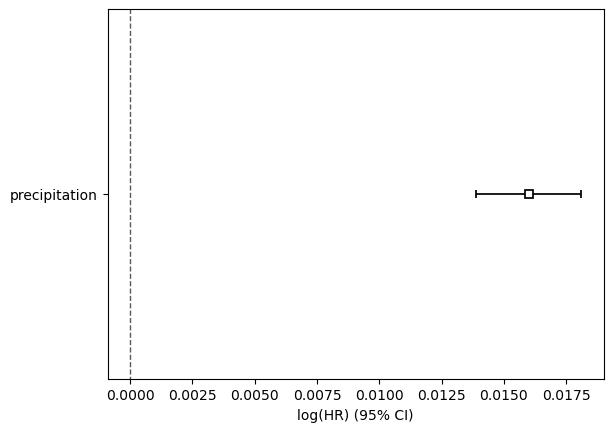

In [11]:
from lifelines import CoxTimeVaryingFitter

ctv = CoxTimeVaryingFitter()
ctv.fit(fr_tv[['start', 'stop', 'precipitation', 'UfireID', 'ended']], id_col='UfireID', event_col="ended", start_col="start", stop_col="stop", show_progress=True)
ctv.print_summary()
ctv.plot()

### Thoughts

- do I need to implment a formal equation (mabe using the *formula* parameter) to describe the non-linear relationship between precip and expected extinguishing / the non-linearity of precip itself? I am unclear on if letting precip time-vary accounts for it's non linearity. I am also not quite sure how to interpret the parameter. Should I jsut use a base level model with a transform (ie do we expect that the amount of precip is propotional to time, and therefore I could tansform the time bit out and get the precip effect?)
- check if number of precip events > effect than amount of precip, or close.
- Do all the assumption checks and critical thinking
- include co-variates?
- wow fireline stuff
- make fit and test datasets.
- could add percent containment!!!
- 

Fun stuff!!!


- cumsum precipp effect < precip effect < << precip boolean effect

In [12]:
#ctv.check_assumptions(training_df = fr_tv[['start', 'stop', 'precip_bool', 'UfireID', 'ended']], advice = True, show_plots = True,)

#cph.check_assumptions(training_df = reg_fr[['duration', 'ended', 'number_of_rain_events']], advice = True, show_plots = True) # Totally breaks the assumptions, becuase it's non linear a wiebull!

Text(0.5, 1.0, 'Cox Hazards model fit to continious precip values')

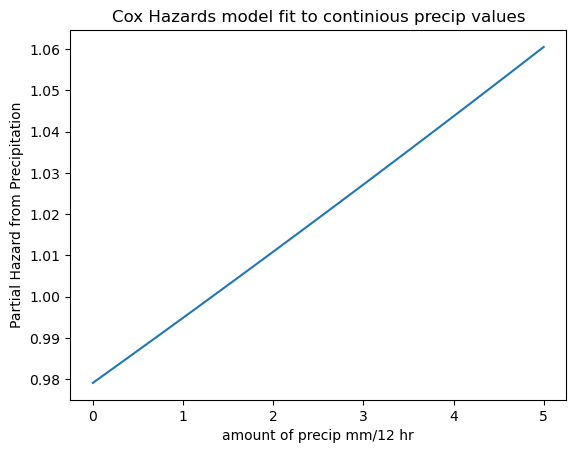

In [22]:
## Make a trial df to show the effect of number of precip events.

## Make a sample tmp
tmp_plot = tmp

tmp_plot.loc[:, 'precipitation']= np.linspace(0, 5, num=len(tmp))
ctv.predict_partial_hazard(tmp_plot[['start', 'stop', 'precipitation']])

plt.plot(tmp_plot.precipitation, ctv.predict_partial_hazard(tmp_plot[['start', 'stop', 'precipitation']]))
plt.ylabel("Partial Hazard from Precipitation")
plt.xlabel("amount of precip mm/12 hr")
plt.title("Cox Hazards model fit to continious precip values")


#tmp_plot.loc[:, 'precip_bool'] = [False, True, False, False, False, False, False, False, False, False, False, False, False, False]
#ctv.predict_partial_hazard(tmp_plot[['start', 'stop', 'precip_bool']])

Text(0.5, 1.0, 'Cox Hazards model fit to continious precip values')

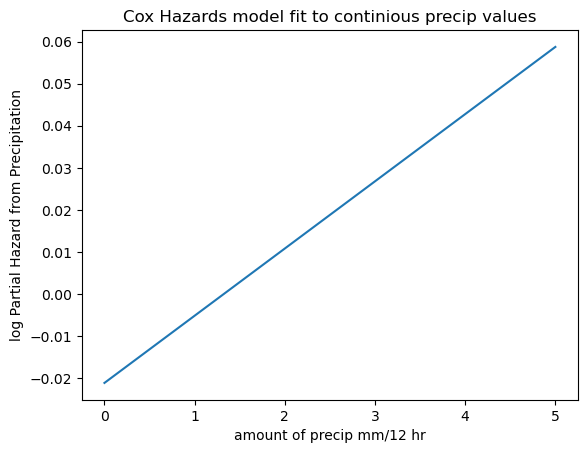

In [21]:
plt.plot(tmp_plot.precipitation, ctv.predict_log_partial_hazard(tmp_plot[['start', 'stop', 'precipitation']]))
plt.ylabel("log Partial Hazard from Precipitation")
plt.xlabel("amount of precip mm/12 hr")
plt.title("Cox Hazards model fit to continious precip values")

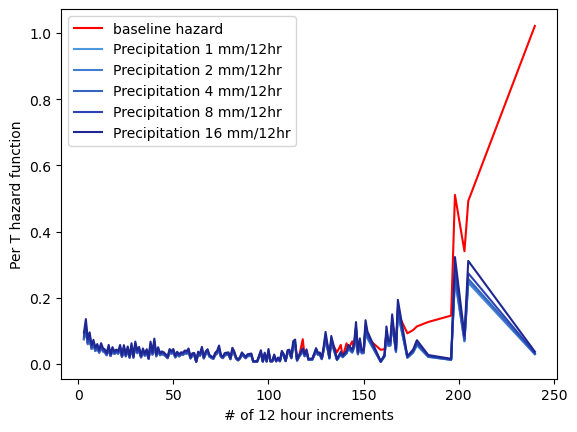

In [137]:
def make_sample_precip_df(start = [], precip_val = 1, max_days = 250, min_days = 0, ):    
    if(len(start) == 0):
        max_days = 250
        min_days = 0
        start_array = range(min_days, max_days)
    else:
        start_array = start
    stop_array  = [x + 1 for x in start_array]
    precipitation = np.repeat([precip_val], len(start_array))

    precip_df = pd.DataFrame({"start": start_array, 
                             "stop": stop_array, 
                             "precipitation": precipitation})
    return(precip_df)

precip_0 = make_sample_precip_df(precip_val = 0, start = ctv.baseline_cumulative_hazard_.index.values)
precip_05 = make_sample_precip_df(precip_val = 0.5, start = ctv.baseline_cumulative_hazard_.index.values)
precip_1 = make_sample_precip_df(precip_val = 1, start = ctv.baseline_cumulative_hazard_.index.values)
precip_2 = make_sample_precip_df(precip_val = 2, start = ctv.baseline_cumulative_hazard_.index.values)
precip_4 = make_sample_precip_df(precip_val = 4, start = ctv.baseline_cumulative_hazard_.index.values)
precip_8 = make_sample_precip_df(precip_val = 8, start = ctv.baseline_cumulative_hazard_.index.values)
precip_16 = make_sample_precip_df(precip_val = 16, start = ctv.baseline_cumulative_hazard_.index.values)
total_haz = ctv.baseline_cumulative_hazard_['baseline hazard']*ctv.predict_partial_hazard(precip_1).unique()

#64B6EE
#4C9ADD
#427BD2
#3364C0
#2C43B0
#1E2791

baseline_h = ctv.baseline_cumulative_hazard_['baseline hazard'].diff() / ctv.baseline_cumulative_hazard_.index.diff() 

ctv.baseline_cumulative_hazard_.diff().plot( color = "red")  
#plt.plot(precip_05.start, total_haz, color = "#64B6EE", label = "Precipitation 0.5 mm/12hr")

#ctv.baseline_cumulative_hazard_['baseline hazard'].diff()


# plt.plot(precip_1.start, ctv.baseline_cumulative_hazard_['baseline hazard'].diff()*ctv.predict_partial_hazard(precip_1).unique(), color = "#4C9ADD", label = "Precipitation 1 mm/12hr")
# plt.plot(precip_2.start, ctv.baseline_cumulative_hazard_['baseline hazard'].diff()*ctv.predict_partial_hazard(precip_2).unique(), color = "#427BD2", label = "Precipitation 2 mm/12hr")
# plt.plot(precip_4.start, ctv.baseline_cumulative_hazard_['baseline hazard'].diff()*ctv.predict_partial_hazard(precip_4).unique(), color = "#3364C0", label = "Precipitation 4 mm/12hr")
# plt.plot(precip_8.start, ctv.baseline_cumulative_hazard_['baseline hazard'].diff()*ctv.predict_partial_hazard(precip_8).unique(), color = "#2C43B0", label = "Precipitation 8 mm/12hr")
# plt.plot(precip_16.start, ctv.baseline_cumulative_hazard_['baseline hazard'].diff()*ctv.predict_partial_hazard(precip_16).unique(), color = "#1E2791", label = "Precipitation 16 mm/12hr")

plt.plot(precip_1.start, baseline_h*ctv.predict_partial_hazard(precip_1).unique(), color = "#4C9ADD", label = "Precipitation 1 mm/12hr")
plt.plot(precip_2.start, baseline_h*ctv.predict_partial_hazard(precip_2).unique(), color = "#427BD2", label = "Precipitation 2 mm/12hr")
plt.plot(precip_4.start, baseline_h*ctv.predict_partial_hazard(precip_4).unique(), color = "#3364C0", label = "Precipitation 4 mm/12hr")
plt.plot(precip_8.start, baseline_h*ctv.predict_partial_hazard(precip_8).unique(), color = "#2C43B0", label = "Precipitation 8 mm/12hr")
plt.plot(precip_16.start, baseline_h*ctv.predict_partial_hazard(precip_16).unique(), color = "#1E2791", label = "Precipitation 16 mm/12hr")

plt.ylabel("Per T hazard function")
plt.xlabel("# of 12 hour increments")
plt.legend()

In [ ]:
ctv.baseline_cumulative_hazard_.plot( color = "red")
plt.plot(precip_0.start, ctv.baseline_cumulative_hazard_['baseline hazard']*ctv.predict_partial_hazard(precip_0).unique())

print("Note: the baseline hazard is not equal to the hazard when precip is 0. Precip being zero actually decreases the hazard a little bit")
print("wait, is this wrong? I though this was giving me the hazard function, but I think it's giving me the cummulative hazard function, which I am not sure I can actually multiple by the partial hazard like this. I looked, and other people have run into this same problem")
# https://github.com/CamDavidsonPilon/lifelines/issues/530#issuecomment-733800440
# https://github.com/CamDavidsonPilon/lifelines/discussions/1522

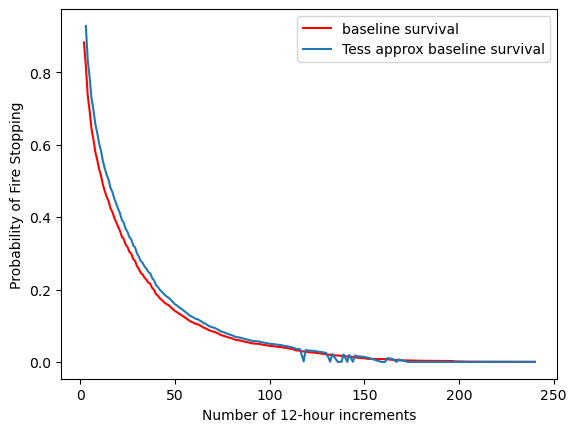

Does the test curve look similar to the supplied curve???. It looks similar, but there are CLEARLY some assumptions going on. I can't tell if this is my math, indexing issues, or that I am using differencing to approximate my integral & derivative
I am going to proceed under the assumtion that the differences are down to the integral approximation, and that plotting up my derived survival terms is still a useful excersize for gaining intuition.


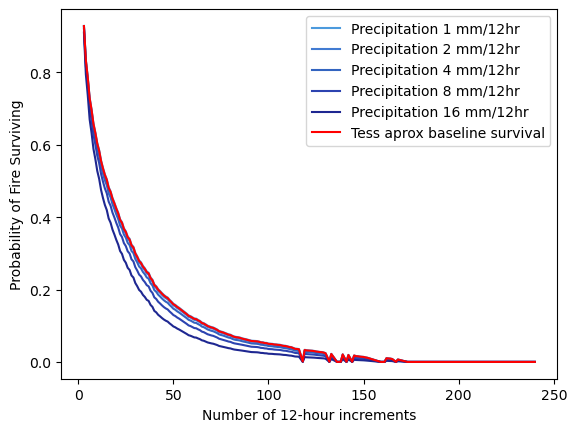

In [209]:
# def derive_con_survivial_func( ctv, vals = [0, 0.5, 1, 2, 4, 8, 16], dfs = [precip_0, precip_05, precip_1, precip_2 , precip_4, precip_8, precip_16]):
from scipy.interpolate import interp1d

def calc_survive(ctv, df):
    baseline_h = ctv.baseline_cumulative_hazard_['baseline hazard'].diff() / ctv.baseline_cumulative_hazard_.index.diff()
    precip_vals = ctv.predict_partial_hazard(df).unique()
    h_func = baseline_h * precip_vals

    ## survivor function
    integral_of_h = np.exp((np.cumsum(h_func) * ctv.baseline_cumulative_hazard_.index.diff()) * - 1) ## Does the step size matter?????? Apply smoothing function to force step size of 1?????
    return(integral_of_h)

def check_calc_survive(ctv, plot = True):
    baseline_h = ctv.baseline_cumulative_hazard_['baseline hazard'].diff() / ctv.baseline_cumulative_hazard_.index.diff()
    integral_of_h = np.exp((np.cumsum(baseline_h) * ctv.baseline_cumulative_hazard_.index.diff()) * - 1)
    if plot:
        
        ctv.baseline_survival_.plot(color = "red")
        plt.plot(ctv.baseline_cumulative_hazard_.index, integral_of_h, label = "Tess approx baseline survival")
        plt.ylabel("Probability of Fire Stopping")
        plt.xlabel("Number of 12-hour increments")
        plt.legend()
        plt.show()
    return(integral_of_h) ## Should match the baseline survivor function

def calc_cummulative_hazard(ctv, df):
    baseline_h = ctv.baseline_cumulative_hazard_['baseline hazard'].diff() / ctv.baseline_cumulative_hazard_.index.diff()
    precip_vals = ctv.predict_partial_hazard(df).unique()
    h_func = baseline_h * precip_vals

    ## survivor function
    integral_of_h = (np.cumsum(h_func) * ctv.baseline_cumulative_hazard_.index.diff()) ## Does the step size matter?????? Apply smoothing function to force step size of 1?????
    return(integral_of_h)
    
    

check_calc_survive(ctv)
print("Does the test curve look similar to the supplied curve???. It looks similar, but there are CLEARLY some assumptions going on. I can't tell if this is my math, indexing issues, or that I am using differencing to approximate my integral & derivative")
print("I am going to proceed under the assumtion that the differences are down to the integral approximation, and that plotting up my derived survival terms is still a useful excersize for gaining intuition.")



def derive_con_survivial_func( ctv, vals = [ 1, 2, 4, 8, 16], dfs = [ precip_1, precip_2 , precip_4, precip_8, precip_16], colors = [ '#4C9ADD', '#427BD2', '#3364C0', '#2C43B0', '#1E2791']): # '#64B6EE','#64B6EE',
    #ctv.baseline_survival_.plot(color = "red")
    
    for i,v in enumerate(vals):
        plt.plot(ctv.baseline_cumulative_hazard_.index, calc_survive(ctv = ctv, df = dfs[i]), color = colors[i], label = f"Precipitation {v} mm/12hr")
    plt.plot(ctv.baseline_cumulative_hazard_.index, check_calc_survive(ctv, plot = False), color = "red", label = "Tess aprox baseline survival")
    #ctv.baseline_survival_.plot(color = "red")
    plt.ylabel("Probability of Fire Surviving")
    plt.xlabel("Number of 12-hour increments")
    plt.legend()
    plt.show()
        
derive_con_survivial_func(ctv)

def plot_hazard( ctv, vals = [ 1, 2, 4, 8, 16], dfs = [ precip_1, precip_2 , precip_4, precip_8, precip_16], colors = [ '#4C9ADD', '#427BD2', '#3364C0', '#2C43B0', '#1E2791']): # '#64B6EE','#64B6EE',
    ctv.baseline_cumulative_hazard_.plot(color = "red")
    #plt.plot(ctv.baseline_cumulative_hazard_.index, check_calc_survive(ctv, plot = False), color = "red", label = "Tess aprox baseline survival")
    for i,v in enumerate(vals):
        plt.plot(ctv.baseline_cumulative_hazard_.index, calc_cummulative_hazard(ctv = ctv, df = dfs[i]).values, color = colors[i], label = f"Precipitation {v} mm/12hr")
    plt.ylabel("Cummulative Hazard")
    plt.xlabel("Number of 12-hour increments")
    plt.legend()
    plt.show()

#plot_hazard(ctv) ## This looks terrible

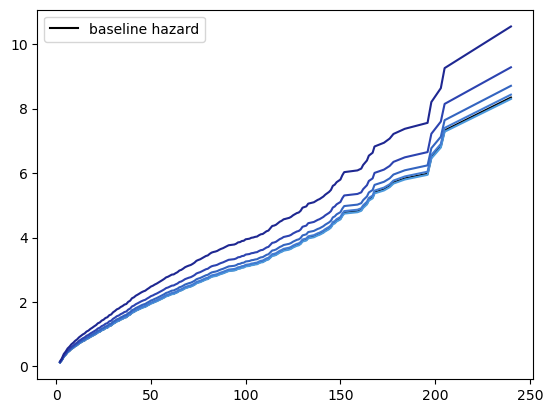

In [85]:
c

[]

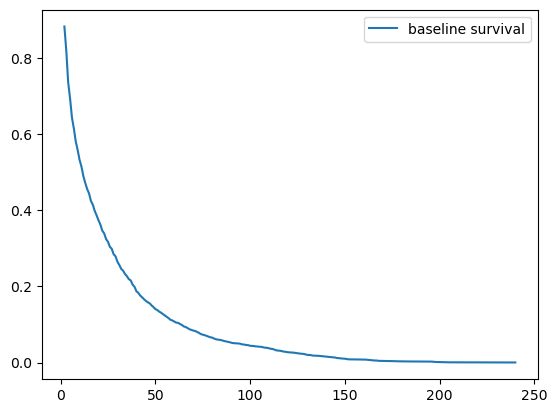

In [25]:
### Ok, tess tries to plot the precipitation-mediated survival probability
ctv.baseline_survival_.plot()
plt.plot()
plt.ylabel("Survival until next 12 hour increment")
plt.xlabel("# of 12 hour increments")

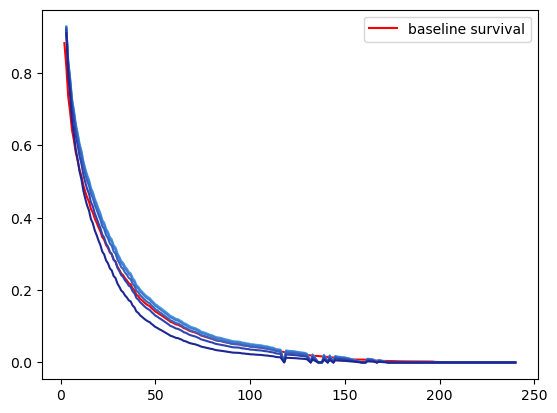

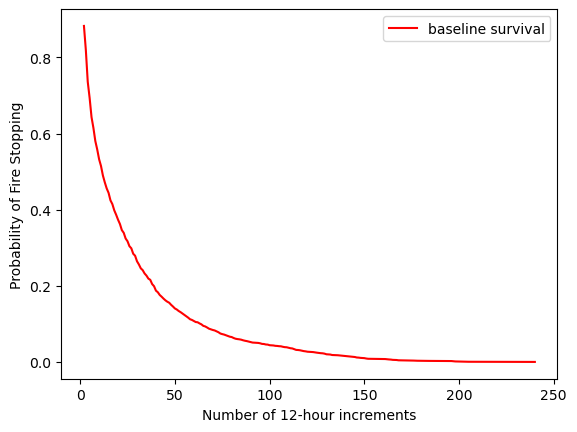

In [206]:
derive_con_survivial_func(ctv)